# ML4Net - Lab 3

## Team members

Melker Svensson (242994), Felipe López (266687), Raúl Martín (267819)

## Description

In this lab, you will train a time series forecaster using Federated Learning (FL).

The dataset you are going to use contains data from multiple APs. In particular, each AP's dataset contains the following features:

* `datetime` is the timestamp (date) at which the measurement was taken
* `Bytes` is the number of Bytes contributed at the corresponding datetime
* `Active Connections` is the number of active connections (users connected to the AP) at the corresponding datetime
* `Active Users` is the number of active users at the corresponding datetime
* `AP ID` is the ID of the AP where the measurement was taken

Original dataset: Chen, W., Lyu, F., Wu, F., Yang, P., & Ren, J. (2021). Flag: Flexible, accurate, and long-time user load prediction in large-scale WiFi system using deep RNN. IEEE Internet of Things Journal, 8(22), 16510-16521.

## Instructions

*   Follow the steps from this Notebook and complete the proposed exercises.
*   Deliver the completed Notebook by uploading it to your Github repository.
*   **Submission deadline: 8 June 2026 (EoB).**

## Setting up the environment

1. Connect your Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Download the dataset

In [3]:
# !wget https://github.com/fwilhelmi/fwilhelmi.github.io/blob/master/files/datasetLab3.pkl

3. Define the main path of the code

In [4]:
mypath="drive/MyDrive/AAX/Lab3"

4. Extract the source code to the destination folder

In [5]:
# mkdir $mypath; cp datasetLab3.pkl $mypath; cd $mypath;

## Loading the data




Load the data from the pickle file (https://docs.python.org/3/library/pickle.html) that contains the dataset.

**Important:** If you have issues with the dataset after automatically downloading and extracting it, download it and move it manually to the indicated folder.

In [6]:
%cd $mypath

/content/drive/MyDrive/AAX/Lab3


In [7]:
import pickle
import os

print(os.getcwd())
print(os.path.exists('datasetLab3.pkl'))

# Open and load the pickle file
try:
    with open('datasetLab3.pkl', 'rb') as f:
        loaded_data = pickle.load(f)
    print("Data loaded successfully:")
    print(loaded_data)
except FileNotFoundError:
    print("Error: 'datasetLab3.pkl' not found.")
except Exception as e:
    print(f"An error occurred: {e}")

/content/drive/MyDrive/AAX/Lab3
True
Data loaded successfully:
                     Bytes  Active Connections  Active Users   AP ID
datetime                                                            
2019-04-30 07:10:00    0.0            0.075209           0.0  7-1012
2019-04-30 07:20:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:30:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:40:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:50:00    0.0            0.000000           0.0  7-1012
...                    ...                 ...           ...     ...
2019-05-14 07:10:00    0.0            0.000000           0.0   7-104
2019-05-14 07:20:00    0.0            0.000000           0.0   7-104
2019-05-14 07:30:00    0.0            0.000000           0.0   7-104
2019-05-14 07:40:00    0.0            0.000000           0.0   7-104
2019-05-14 07:50:00    0.0            0.034091           0.0   7-104

[211064 rows x 4 columns]


## EXERCISES

### Exercise 1:

Analyze the data from the different APs and discuss their properites (stationarity, trends, seasonality).

Select 2 or 3 key APs showing different properties and generate:

* Line plots (to plot the load vs the time)
* Autocorrelation plots (to show the relationship between past and future samples of the load)
* An Augmented Dickey-Fuller test (to study the stationarity of the AP)



In [8]:
# (response to exercise 1)
print(loaded_data.head(10))

                     Bytes  Active Connections  Active Users   AP ID
datetime                                                            
2019-04-30 07:10:00    0.0            0.075209           0.0  7-1012
2019-04-30 07:20:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:30:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:40:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:50:00    0.0            0.000000           0.0  7-1012
2019-04-30 08:00:00    0.0            0.000000           0.0  7-1012
2019-04-30 08:10:00    0.0            0.028333           0.0  7-1012
2019-04-30 08:20:00    0.0            0.000000           0.0  7-1012
2019-04-30 08:30:00    0.0            0.000000           0.0  7-1012
2019-04-30 08:40:00    0.0            0.000000           0.0  7-1012


In [9]:
# dataset head
print(loaded_data.describe())

              Bytes  Active Connections   Active Users
count  2.110640e+05       211064.000000  211064.000000
mean   3.693131e+04            1.582982       1.200613
std    1.441261e+05            4.446037       3.739401
min    0.000000e+00            0.000000       0.000000
25%    0.000000e+00            0.000000       0.000000
50%    0.000000e+00            0.000000       0.000000
75%    2.680175e+03            1.353333       1.000000
max    3.993286e+06          103.780000      79.000000


In [10]:
# Get the minimum and maximum dates from the index
start_date = loaded_data.index.min()
end_date = loaded_data.index.max()

# Calculate the total duration span
duration = end_date - start_date

print(f"Start Date: {start_date}")
print(f"End Date:   {end_date}")
print(f"Total Span: {duration}")

Start Date: 2019-04-28 11:40:00
End Date:   2019-05-15 00:10:00
Total Span: 16 days 12:30:00


#### Helper functions

Below we provide a function for generating line plots for a given AP. We do not visualize "Active Users" as data is very similar to "Active Connections".

In [ ]:
import matplotlib.pyplot as plt


def line_plot(df, ap_id):

    # 1. Filter the dataset for the specified AP ID
    ap_data = df[df["AP ID"] == ap_id]

    # Check if the AP exists in the data
    if ap_data.empty:
        print(f"Warning: AP ID '{ap_id}' not found in the dataset.")
        print(f"Available AP IDs include: {list(df['AP ID'].unique()[:5])}...")
        return

    # 2. Initialize a figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 3. Plot 1: Time vs. Bytes
    axes[0].plot(ap_data.index, ap_data["Bytes"], color="#1f77b4", linewidth=1.2)
    axes[0].set_title(f"AP {ap_id} - Bytes over Time", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Date/Time", fontsize=11)
    axes[0].set_ylabel("Bytes Contributed", fontsize=11)
    axes[0].grid(True, linestyle="--", alpha=0.5)
    axes[0].tick_params(axis="x", rotation=30)  # Rotate dates for better readability

    # 4. Plot 2: Time vs. Connected Users (Active Connections)
    axes[1].plot(
        ap_data.index, ap_data["Active Connections"], color="#2ca02c", linewidth=1.2
    )
    axes[1].set_title(
        f"AP {ap_id} - Active Connections over Time", fontsize=14, fontweight="bold"
    )
    axes[1].set_xlabel("Date/Time", fontsize=11)
    axes[1].set_ylabel("Active Connections", fontsize=11)
    axes[1].grid(True, linestyle="--", alpha=0.5)
    axes[1].tick_params(axis="x", rotation=30)  # Rotate dates for better readability

    # 5. Automatically adjust spacing between plots
    plt.tight_layout()
    plt.show()

Function for generating autocorrelation plots, using statsmodels library:

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf


def correlation_plots(df, ap_id, lags=None):

    # 1. Filter the dataset for the specified AP ID
    ap_data = df[df["AP ID"] == ap_id]

    # deterimne num of lags if it's none
    if lags is None:
        lags = len(ap_data) - 1

    # Check if the AP exists in the data
    if ap_data.empty:
        print(f"Warning: AP ID '{ap_id}' not found in the dataset.")
        return

    # 2. Initialize a figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # 3. Plot 1: Autocorrelation of Bytes
    # We drop NaN values (if any) to prevent statsmodels from erroring
    plot_acf(ap_data["Bytes"].dropna(), lags=lags, ax=axes[0], color="#1f77b4")
    axes[0].set_title(
        f"AP {ap_id} - Bytes Autocorrelation", fontsize=13, fontweight="bold"
    )
    axes[0].set_xlabel("Lags (10-minute intervals)", fontsize=11)
    axes[0].set_ylabel("Autocorrelation Coefficient", fontsize=11)
    axes[0].grid(True, linestyle="--", alpha=0.5)

    # 4. Plot 2: Autocorrelation of Connected Users (Active Connections)
    plot_acf(
        ap_data["Active Connections"].dropna(), lags=lags, ax=axes[1], color="#2ca02c"
    )
    axes[1].set_title(
        f"AP {ap_id} - Active Connections Autocorrelation",
        fontsize=13,
        fontweight="bold",
    )
    axes[1].set_xlabel("Lags (10-minute intervals)", fontsize=11)
    axes[1].set_ylabel("Autocorrelation Coefficient", fontsize=11)
    axes[1].grid(True, linestyle="--", alpha=0.5)

    # 5. Automatically adjust layout spacing
    plt.tight_layout()
    plt.show()

Function for performing the Augmented Dickey-Fuller test, also using statsmodels library:

In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller


def perform_adf_test(df, ap_id):

    # 1. Filter the dataset for the specified AP ID
    ap_data = df[df["AP ID"] == ap_id]

    if ap_data.empty:
        print(f"Warning: AP ID '{ap_id}' not found in the dataset.")
        return

    variables = ["Bytes", "Active Connections"]

    print("=" * 60)
    print(f"AUGMENTED DICKEY-FULLER TEST FOR AP: {ap_id}")
    print("=" * 60)

    for var in variables:
        series = ap_data[var].dropna()

        print(f"\n--- Testing Variable: {var} ---")

        # Check if the series is constant (e.g., all zeros)
        if series.nunique() <= 1:
            print(
                f"Result: The series for '{var}' is constant (all values are {series.iloc[0]})."
            )
            print(
                "A constant series is technically stationary, but the ADF test cannot be calculated."
            )
            continue

        try:
            # Run the ADF test
            result = adfuller(series)

            print(f"ADF Statistic: {result[0]:.4f}")
            print(f"p-value:       {result[1]:.4e}")

            # Interpret the result (commonly using a 5% significance level)
            if result[1] < 0.05:
                print("\nConclusion: p-value < 0.05. Reject the null hypothesis.")
                print(f"            The '{var}' series is STATIONARY.")
            else:
                print(
                    "\nConclusion: p-value >= 0.05. Fail to reject the null hypothesis."
                )
                print(f"            The '{var}' series is NON-STATIONARY.")

        except Exception as e:
            print(f"Could not perform ADF test on '{var}': {e}")

    print("=" * 60)

#### 1) AP: 7-1012

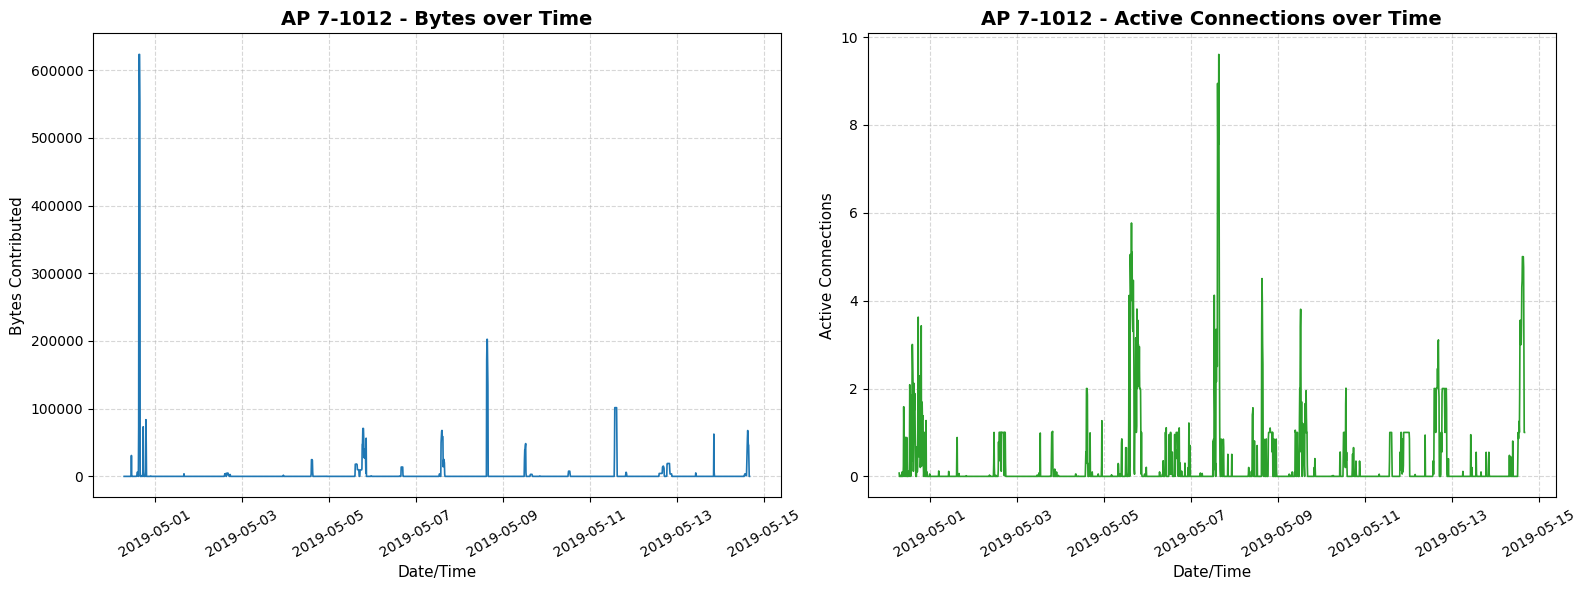

In [14]:
line_plot(loaded_data, '7-1012')

For this first AP, we can see that there is a huge peak on contributed bytes at the start of measurements, corresponding to 0.6MB. After that, the contributed bytes mantain near zero, with other lower peaks such as a 0.2MB operation near 05/09. In this case, the trend is not clear, although the first high peak suggests that there was a high load at the start of measurements, which then decreased and mantained low.

The plot on the right shows that the number of active connections varies from 0 to 10, with a peak of 9-10 connections near 05/08. We can also see some seasonality as the number of connections falls after the start of a new day, representing the night hours.

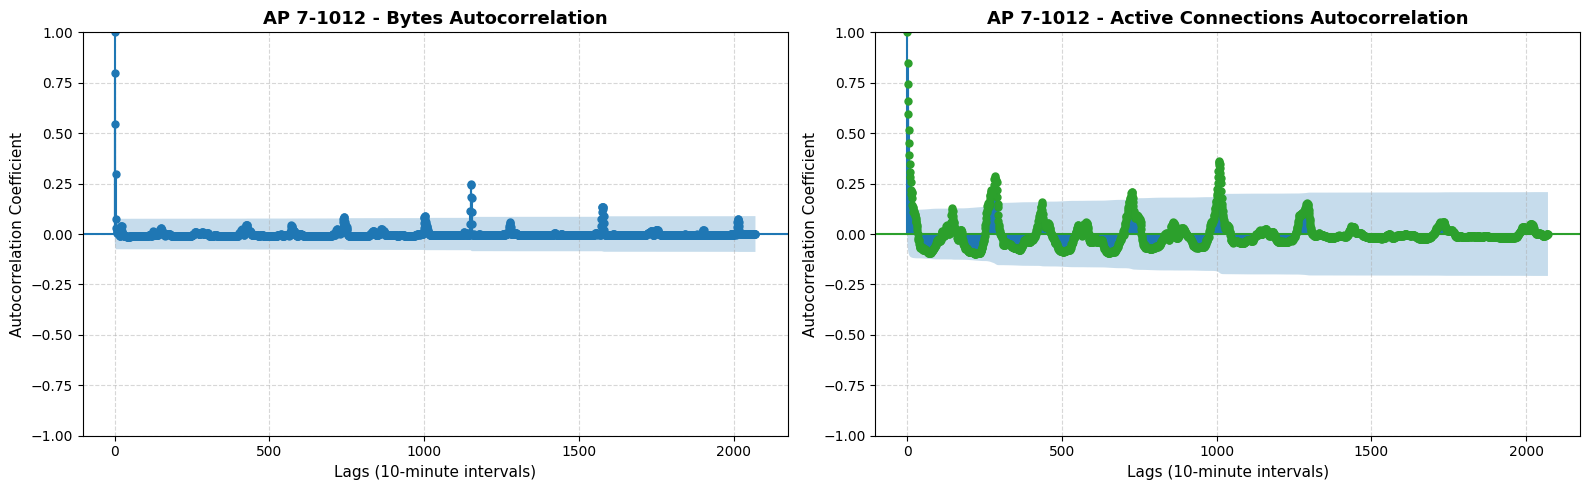

In [15]:
correlation_plots(loaded_data, '7-1012', lags=None)

The autocorrelation plots show that the Bytes variable seems to be stationary, as it quickly drops and stays inside the blue area. The Active Connections variable also seems to be stationary, but a more clear seasonality can be observed. The sequence repeats in intervals of 140 logs, indicating a daily pattern (as there are 144 logs per day).

In [16]:
perform_adf_test(loaded_data, '7-1012')

AUGMENTED DICKEY-FULLER TEST FOR AP: 7-1012

--- Testing Variable: Bytes ---
ADF Statistic: -8.0108
p-value:       2.2038e-12

Conclusion: p-value < 0.05. Reject the null hypothesis.
            The 'Bytes' series is STATIONARY.

--- Testing Variable: Active Connections ---
ADF Statistic: -6.2715
p-value:       3.9942e-08

Conclusion: p-value < 0.05. Reject the null hypothesis.
            The 'Active Connections' series is STATIONARY.


The ADF test confirms that both variables are stationary, as the p-value is much lower than 0.05.

#### 2) AP 7-104

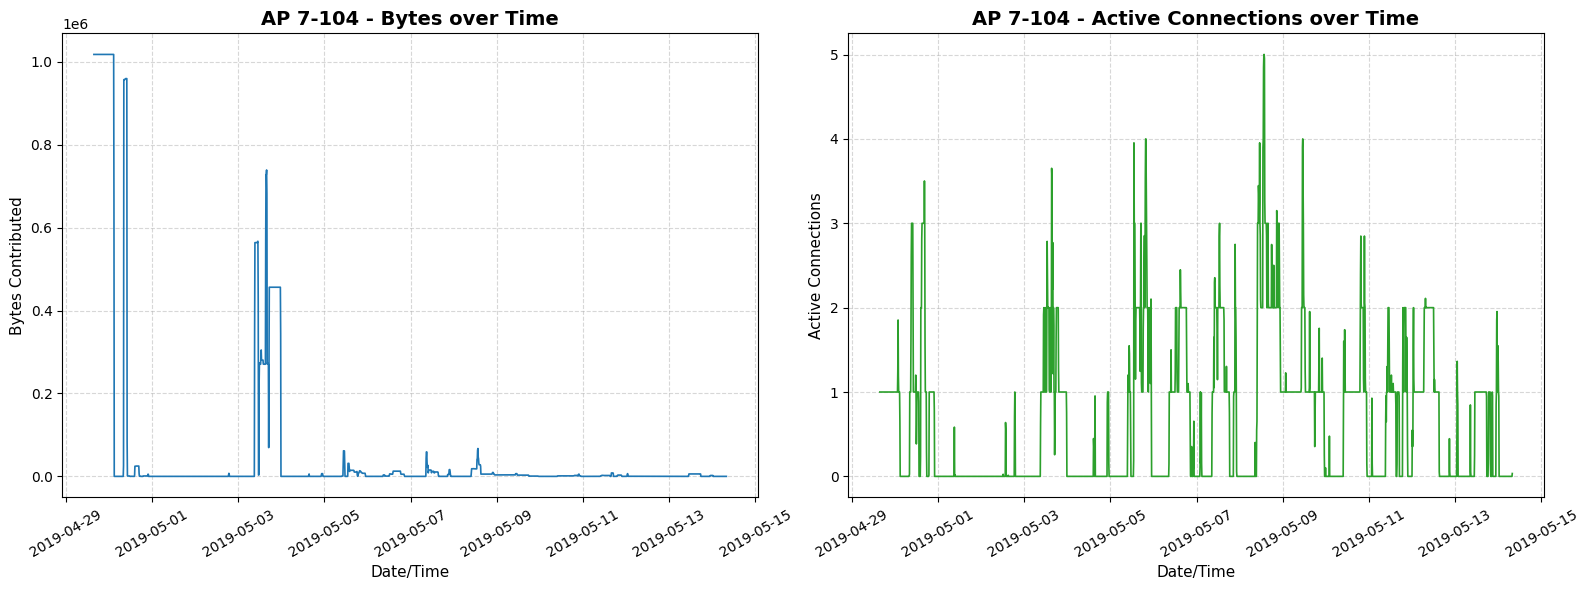

In [17]:
line_plot(loaded_data, '7-104')

For this new AP, we see that the contributed bytes are in general much lower than the previous. We see peaks on 28/4 and 3/5, but they correspond to 1 and 0.7 bytes only. The rest of the measurements are very close to zero, with no clear trend. The number of active connections is also lower than the previous AP, with a maximum of 5, highliting that different APs may have different load distributions.

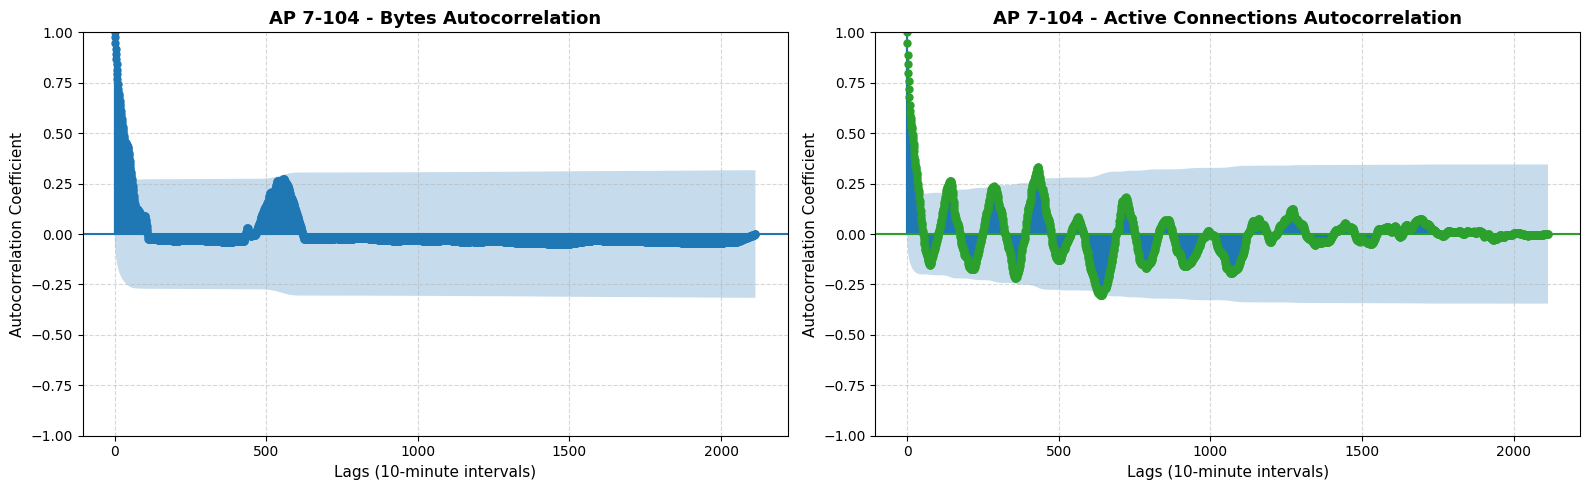

In [18]:
correlation_plots(loaded_data, '7-104', lags=None)

The autocorrelation plots first show that the contributed bytes may involve a seasonality of around 540 logs, which corresponds to approximately 4 days. Similarly to the previous AP, the active connections also show a seasonality of around 140 logs (daily pattern).

In [19]:
perform_adf_test(loaded_data, '7-104')

AUGMENTED DICKEY-FULLER TEST FOR AP: 7-104

--- Testing Variable: Bytes ---
ADF Statistic: -5.8506
p-value:       3.5967e-07

Conclusion: p-value < 0.05. Reject the null hypothesis.
            The 'Bytes' series is STATIONARY.

--- Testing Variable: Active Connections ---
ADF Statistic: -4.9681
p-value:       2.5660e-05

Conclusion: p-value < 0.05. Reject the null hypothesis.
            The 'Active Connections' series is STATIONARY.


The ADF test shows that both variables are also stationary for this second AP. However, p-values are higher than for the previous AP, indicating that stationarity is slightly less clear for this AP.

#### 3) AP 7-103

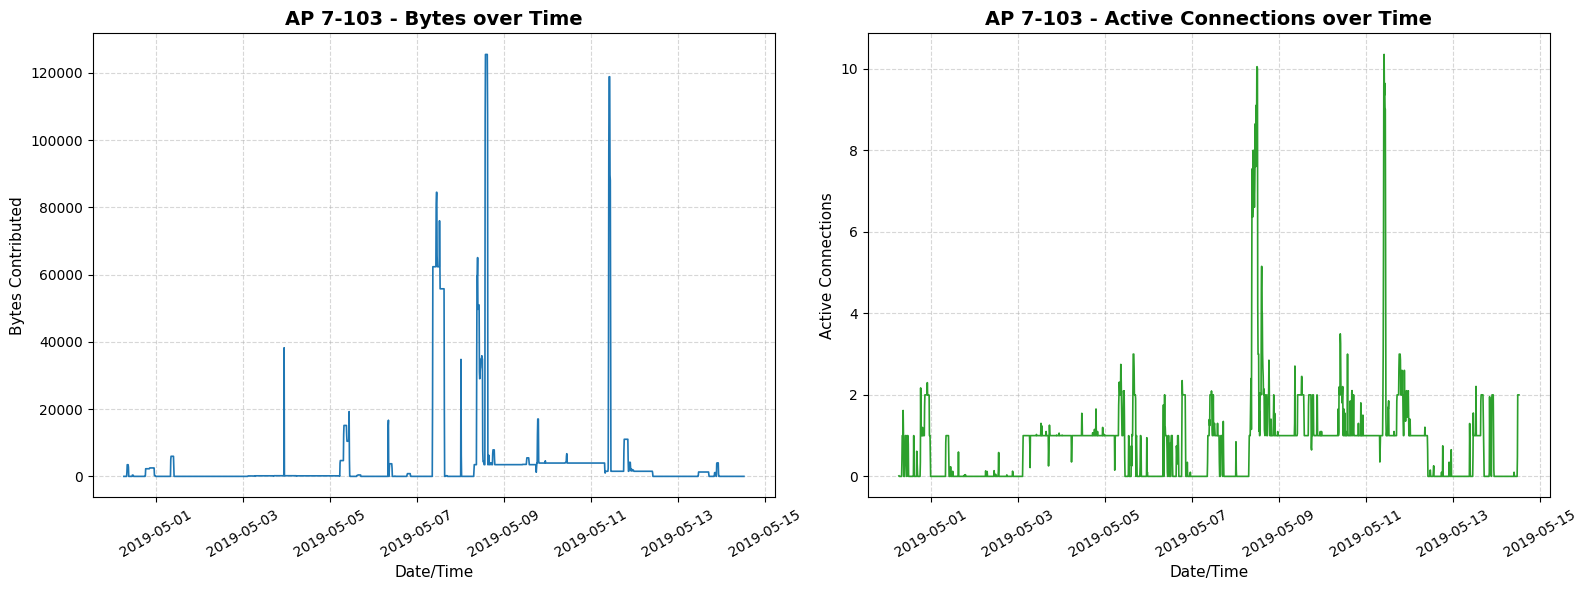

In [20]:
line_plot(loaded_data, '7-103')

The line plot on the left shows that contributed bytes range from 0 to 0.12MB, with high peaks on 7/5, 8/5 and 11/5, with no clear trends. The plot on the right shows that the number of active connections now spans 0-10, with peaks on 8/5 and 11/5, which correspond to the peaks on contributed bytes. This is different as for the previous APs, where peaks in both variables did not strongly coincide. Additionally, we observe that these peaks correspond to a high-load period between 8/5 and 12/5.

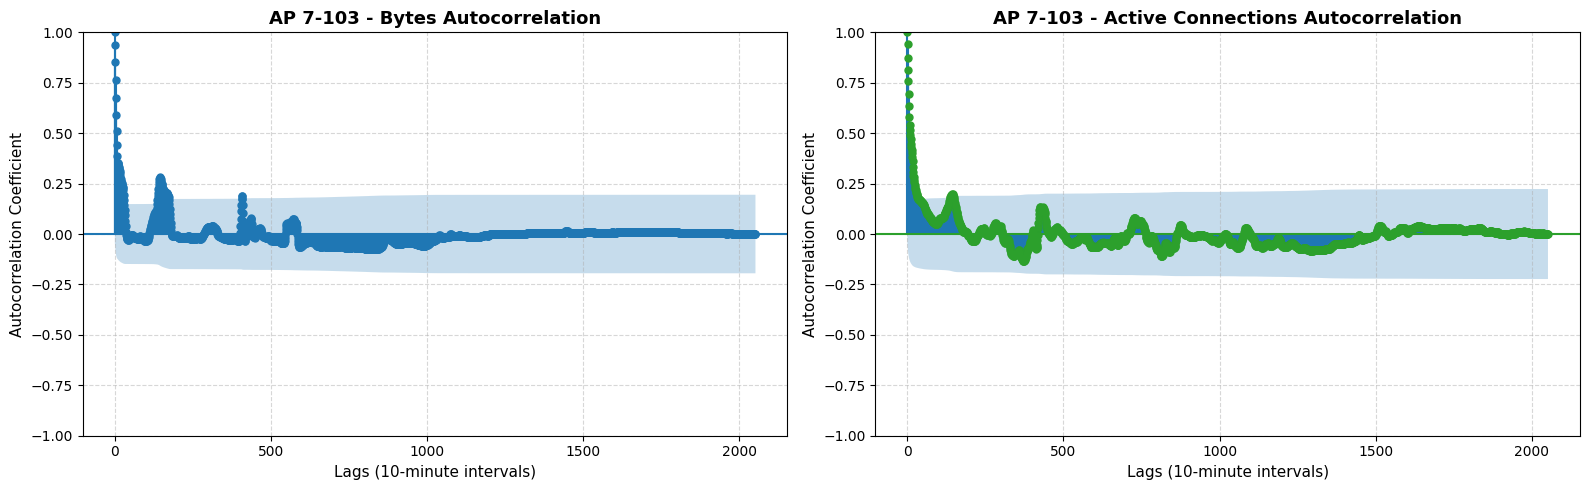

In [21]:
correlation_plots(loaded_data, '7-103', lags=None)

The autocorrelation plot for the contributed bytes shows a peak in correlation at around lag 144, corresponding to 1 day, similar to the previous APs. However, besides this seasonality, it seems that the sequence is not repeated in intervals of 144. This represents correlations with the previous day, but not earlier days.

In [22]:
perform_adf_test(loaded_data, '7-103')

AUGMENTED DICKEY-FULLER TEST FOR AP: 7-103

--- Testing Variable: Bytes ---
ADF Statistic: -7.2947
p-value:       1.3879e-10

Conclusion: p-value < 0.05. Reject the null hypothesis.
            The 'Bytes' series is STATIONARY.

--- Testing Variable: Active Connections ---
ADF Statistic: -5.7715
p-value:       5.3784e-07

Conclusion: p-value < 0.05. Reject the null hypothesis.
            The 'Active Connections' series is STATIONARY.


The ADF test shows that both variables are again stationary for this third AP.

### Exercise 2:

Prepare the data to be presented as a time series to the ML model. For that, you will have to split features from samples by differentiating between an observation window (e.g., 10 samples) and a prediction window (e.g., 2 samples). Use a sliding window to iterate over all the samples.

Example: For an array [0,1,2,3,4,5], using an observation window $T_o$ = 3 and a prediction window $T_p$ = 1 would lead to the following time series data:
* $x_1$ = [0,1,2], $y_1$ = [3]
* $x_2$ = [1,2,3], $x_2$ = [4]
* $x_3$ = [2,3,4], $y_3$ = [5]

(where x are the features and y the labels)

In our case, we will take "Active Connections" as our prediction target, as it represents a consistent measure of AP load and, based on our previous exploratory analysis, it involves more clear patterns than the contributed bytes feature. Therefore, we will feed our model with data of this specific variable only, since "Active Users" does not add much information (it depends on the number of active connections).

#### Helper functions

We define functions to generate the sliding windows for each AP.

In [ ]:
import numpy as np
import pandas as pd


def create_sliding_windows(data, T_o, T_p):

    # Convert pandas Series to numpy array if necessary
    if hasattr(data, "values"):
        data = data.values

    X = []
    Y = []

    # Total length of one window (past + future)
    window_size = T_o + T_p

    # Slide the window across the series
    for i in range(len(data) - window_size + 1):
        x_window = data[i : i + T_o]
        y_window = data[i + T_o : i + window_size]
        X.append(x_window)
        Y.append(y_window)

    return np.array(X), np.array(Y)


def prepare_data_by_ap(df, T_o, T_p):

    ap_dataset_dict = {}
    unique_aps = df["AP ID"].unique()

    print(
        f"Preparing sliding windows (T_o={T_o}, T_p={T_p}) for {len(unique_aps)} APs..."
    )

    for ap_id in unique_aps:
        # Filter and ensure data is sorted chronologically
        ap_data = df[df["AP ID"] == ap_id].sort_index()

        # Extract the target column: 'Active Connections'
        series = ap_data["Active Connections"]

        # Only process if there's enough data to form at least one window
        if len(series) >= (T_o + T_p):
            X_ap, Y_ap = create_sliding_windows(series, T_o, T_p)
            ap_dataset_dict[ap_id] = (X_ap, Y_ap)

    print("Done! Data prepared successfully.")
    return ap_dataset_dict

#### Configure windows

We will use 12 samples for the observation window (2 hours) and 3 for the prediction window (30 minutes). These small windows are configured for fast training and a first performance overview of the model.

In [9]:
# Configure windows
T_o = 12
T_p = 3

# Prepare the data dictionary
ap_data_dict = prepare_data_by_ap(loaded_data, T_o, T_p)

# Let's inspect the shapes for a sample AP ID
sample_ap = "7-1012"
X_sample, Y_sample = ap_data_dict[sample_ap]

print(f"\nInspection for AP {sample_ap}:")
print(f"  X shape: {X_sample.shape}  -> (num_samples, T_o)")
print(f"  Y shape: {Y_sample.shape}  -> (num_samples, T_p)")

# Print a concrete example of one window
print("\nExample Window 0:")
print(f"  Input features (X[0]): {X_sample[0]}")
print(f"  Target labels  (Y[0]): {Y_sample[0]}")

Preparing sliding windows (T_o=12, T_p=3) for 100 APs...
Done! Data prepared successfully.

Inspection for AP 7-1012:
  X shape: (2057, 12)  -> (num_samples, T_o)
  Y shape: (2057, 3)  -> (num_samples, T_p)

Example Window 0:
  Input features (X[0]): [0.07520891 0.         0.         0.         0.         0.
 0.02833333 0.         0.         0.         0.10166667 0.        ]
  Target labels  (Y[0]): [0.         0.         0.23333333]


Correctness check:

In [10]:
# check how many samples there are for AP 7-1012 in the original dataset
ap_1012_data = loaded_data[loaded_data["AP ID"] == "7-1012"]
num_samples_1012 = len(ap_1012_data)
print(f"\nNumber of samples for AP 7-1012 in the original dataset: {num_samples_1012}")
# first rows of the original dataset for AP 7-1012
print(f"\nFirst 5 rows for AP 7-1012 in the original dataset:")
print(ap_1012_data.head(15))


Number of samples for AP 7-1012 in the original dataset: 2071

First 5 rows for AP 7-1012 in the original dataset:
                     Bytes  Active Connections  Active Users   AP ID
datetime                                                            
2019-04-30 07:10:00   0.00            0.075209      0.000000  7-1012
2019-04-30 07:20:00   0.00            0.000000      0.000000  7-1012
2019-04-30 07:30:00   0.00            0.000000      0.000000  7-1012
2019-04-30 07:40:00   0.00            0.000000      0.000000  7-1012
2019-04-30 07:50:00   0.00            0.000000      0.000000  7-1012
2019-04-30 08:00:00   0.00            0.000000      0.000000  7-1012
2019-04-30 08:10:00   0.00            0.028333      0.000000  7-1012
2019-04-30 08:20:00   0.00            0.000000      0.000000  7-1012
2019-04-30 08:30:00   0.00            0.000000      0.000000  7-1012
2019-04-30 08:40:00   0.00            0.000000      0.000000  7-1012
2019-04-30 08:50:00   0.00            0.101667      0.00

We see that the 15 samples were correctly processed by the window splitting function, as their values remain the same and the shape makes sense (the last window will start at sample 2071-14=2057, since it needs 14 future samples)

### Exercise 3:

Split the time series data into train, test, and validation, based on your criteria.

We will split chronologically using 70-15-15 percentages, and scale the data based on the training set.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np


def split_and_scale_data(ap_data_dict, train_ratio=0.7, val_ratio=0.15):

    split_data = {}
    scalers = {}

    for ap_id, (X_ap, Y_ap) in ap_data_dict.items():
        total_samples = len(X_ap)

        # Calculate split indices
        train_end = int(total_samples * train_ratio)
        val_end = train_end + int(total_samples * val_ratio)

        # Chronological splits
        X_train, Y_train = X_ap[:train_end], Y_ap[:train_end]
        X_val, Y_val = X_ap[train_end:val_end], Y_ap[train_end:val_end]
        X_test, Y_test = X_ap[val_end:], Y_ap[val_end:]

        # MinMaxScaler expects 2D inputs. X_train has shape (num_samples, T_o), which is 2D.
        scaler = MinMaxScaler(feature_range=(0, 1))

        # Flatten X_train to fit a single scaler for 'Active Connections' values
        scaler.fit(X_train.reshape(-1, 1))

        # Scale all partitions (reshape to 2D to scale, then restore shape)
        X_train_scaled = scaler.transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
        Y_train_scaled = scaler.transform(Y_train.reshape(-1, 1)).reshape(Y_train.shape)

        X_val_scaled = scaler.transform(X_val.reshape(-1, 1)).reshape(X_val.shape)
        Y_val_scaled = scaler.transform(Y_val.reshape(-1, 1)).reshape(Y_val.shape)

        X_test_scaled = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)
        Y_test_scaled = scaler.transform(Y_test.reshape(-1, 1)).reshape(Y_test.shape)

        # Store scaled datasets
        split_data[ap_id] = {
            "train": (X_train_scaled, Y_train_scaled),
            "val": (X_val_scaled, Y_val_scaled),
            "test": (X_test_scaled, Y_test_scaled),
        }

        # Store scaler for inverse transform later
        scalers[ap_id] = scaler

    print(f"Splits and scaling completed for {len(split_data)} APs.")
    return split_data, scalers

In [12]:
# Split and scale the data
split_data, scalers = split_and_scale_data(ap_data_dict)

# Verify splits for our sample AP
sample_ap = "7-1012"
ap_splits = split_data[sample_ap]

print(f"\nVerification for AP {sample_ap}:")
for partition in ["train", "val", "test"]:
    X_part, Y_part = ap_splits[partition]
    print(f"  {partition.capitalize()} set: X={X_part.shape}, Y={Y_part.shape}")

# Verify that the scaling maps data to [0, 1] range
X_train_sample, Y_train_sample = ap_splits["train"]
print(f"\nScaled range check (Train):")
print(f"  Min value in X: {X_train_sample.min():.4f}")
print(f"  Max value in X: {X_train_sample.max():.4f}")

Splits and scaling completed for 100 APs.

Verification for AP 7-1012:
  Train set: X=(1439, 12), Y=(1439, 3)
  Val set: X=(308, 12), Y=(308, 3)
  Test set: X=(310, 12), Y=(310, 3)

Scaled range check (Train):
  Min value in X: 0.0000
  Max value in X: 1.0000


### Exercise 4:
Define a model (e.g., GRU, LSTM, CNN, Transformer) able to receive the time series the data you generated in the previous exercise.

We will define a GRU due to its low complexity and fast training. The other posssible architectures are considerably more complex, and we would like to know if a simpler model already achieves good results. Moreover, our sliding windows are not that long, so we won't obtain the main LSTM benefit. We start with a simple GRU with default parameters: 64 memory units, tanh as activation function, adam optimizer and mean squared error loss.

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import GRU, Dense, Input


def build_gru_model(T_o, T_p):

    model = Sequential(
        [
            # Input layer: shape is (time_steps, features).
            # Here features = 1 (since we are only using 'Active Connections')
            Input(shape=(T_o, 1)),
            # GRU layer with 64 memory units
            GRU(64, activation="tanh", return_sequences=False),
            # Output layer with T_p neurons (predicting T_p steps ahead)
            Dense(T_p),
        ]
    )

    # Compile the model using Adam optimizer and Mean Squared Error loss
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])

    return model

In [14]:
# Build the model using our configured window sizes (T_o=12, T_p=5)
model = build_gru_model(T_o=12, T_p=3)

# Print the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,059 (51.01 KB)

 Trainable params: 13,059 (51.01 KB)

 Non-trainable params: 0 (0.00 B)

### Exercise 5:

Train your model following two approaches:
1. **Centralized model training:** Mix data from multiple APs to train the model in a centralized fashion.
2. **Federated model training:** Consider APs as independent clients who contribute to training a global model by submitting local model updates.

Show the results by calculating the following metrics from the de-normalized data:
* Mean squared error (MSE)
* Mean absolute error (MAE)
* Mean absolute percentage error (MAPE)

First, we define a function for model evaluation, which makes predictions and calculates metrics on the de-normalized data.

In [ ]:
import numpy as np


def evaluate_model_denormalized(model, split_data, scalers, partition="test"):

    all_y_true = []
    all_y_pred = []

    for ap_id in split_data:
        X_scaled, Y_scaled = split_data[ap_id][partition]
        if len(X_scaled) == 0:
            continue

        # Expand dimensions for GRU input: (samples, time_steps, 1)
        X_input = np.expand_dims(X_scaled, axis=-1)

        # Predict using the model
        preds_scaled = model.predict(X_input, verbose=0)

        # De-normalize predictions and actual targets
        scaler = scalers[ap_id]
        preds_denorm = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).reshape(
            preds_scaled.shape
        )
        y_true_denorm = scaler.inverse_transform(Y_scaled.reshape(-1, 1)).reshape(
            Y_scaled.shape
        )

        all_y_true.append(y_true_denorm)
        all_y_pred.append(preds_denorm)

    # Concatenate all test samples across all APs
    all_y_true = np.concatenate(all_y_true, axis=0)
    all_y_pred = np.concatenate(all_y_pred, axis=0)

    # Calculate global metrics on original scale
    mse = np.mean((all_y_true - all_y_pred) ** 2)
    mae = np.mean(np.abs(all_y_true - all_y_pred))

    # For MAPE, ignore cases where actual user count is 0 to avoid division by zero
    non_zero_mask = all_y_true != 0
    if np.sum(non_zero_mask) > 0:
        mape = (
            np.mean(
                np.abs(
                    (all_y_true[non_zero_mask] - all_y_pred[non_zero_mask])
                    / all_y_true[non_zero_mask]
                )
            )
            * 100
        )
    else:
        mape = np.nan

    return mse, mae, mape

#### Centralized training

First, we train the model in a centralized manner, concatenating the data of all APs. We proceed with 10 epochs and a batch size of 64.

In [19]:
def run_centralized_training(split_data, T_o, T_p):

    print("--- Starting Centralized Training ---")

    # Concatenate training and validation data from all APs
    X_train_list, Y_train_list = [], []
    X_val_list, Y_val_list = [], []

    for ap_id in split_data:
        X_train_list.append(split_data[ap_id]["train"][0])
        Y_train_list.append(split_data[ap_id]["train"][1])
        X_val_list.append(split_data[ap_id]["val"][0])
        Y_val_list.append(split_data[ap_id]["val"][1])

    X_train_central = np.concatenate(X_train_list, axis=0)
    Y_train_central = np.concatenate(Y_train_list, axis=0)
    X_val_central = np.concatenate(X_val_list, axis=0)
    Y_val_central = np.concatenate(Y_val_list, axis=0)

    # Expand dimensions for GRU: shape (samples, time_steps, 1)
    X_train_central = np.expand_dims(X_train_central, axis=-1)
    X_val_central = np.expand_dims(X_val_central, axis=-1)

    # Build and train the Centralized GRU model
    central_model = build_gru_model(T_o, T_p)
    history = central_model.fit(
        X_train_central,
        Y_train_central,
        validation_data=(X_val_central, Y_val_central),
        epochs=10,
        batch_size=64,
        verbose=1,
    )
    
    return central_model

In [26]:
# Run centralized training
central_model = run_centralized_training(split_data, T_o=12, T_p=3)

# Evaluate Centralized Model on Test set
cent_mse, cent_mae, cent_mape = evaluate_model_denormalized(
    central_model, split_data, scalers, partition="test"
)
print("\n--- Centralized Model Test Metrics (De-normalized) ---")
print(f"MSE:  {cent_mse:.4f}")
print(f"MAE:  {cent_mae:.4f}")
print(f"MAPE: {cent_mape:.2f}%")

--- Starting Centralized Training ---
Epoch 1/10
2293/2293 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.0074 - mae: 0.0410 - val_loss: 0.0064 - val_mae: 0.0352
Epoch 2/10
2293/2293 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.0071 - mae: 0.0392 - val_loss: 0.0063 - val_mae: 0.0328
Epoch 3/10
2293/2293 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.0071 - mae: 0.0390 - val_loss: 0.0063 - val_mae: 0.0347
Epoch 4/10
2293/2293 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.0071 - mae: 0.0388 - val_loss: 0.0063 - val_mae: 0.0360
Epoch 5/10
2293/2293 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 0.0070 - mae: 0.0387 - val_loss: 0.0064 - val_mae: 0.0376
Epoch 6/10
2293/2293 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 0.0070 - mae: 0.0384 - val_loss: 0.0062 - val_mae: 0.0360
Epoch 7/10
2293/2293 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.0069 - mae: 0.0382 - val_loss: 0.0062 - val_mae: 0.0370
Epoch 8/10
2293/2293 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.0069 - mae: 0.0380 - val_loss: 0.0061 - val_mae: 0

The metrics show that the centralized GRU is highly accurate on average. MAE is 0.53, representing that, on average, the predictions deviate 0.53 from the actual connections number. MSE is quite higher, likely due to the presence of outliers in the data (connection peaks), since this metric penalizes large errors. Finally, MAPE also appears to be high, but probably due to the fact that connection values between 0 and 1 cause a huge increase in percentage error.

#### Federated training

Secondly, we apply federated training, treating each AP as an individual client. We use federated averaging: the clients train locally, pass the weights to the server, and they are averaged taking into account the samples of each client.

In [16]:
import random
import tensorflow as tf


def run_federated_learning_fast(
    split_data,
    scalers,
    T_o,
    T_p,
    rounds=5,
    local_epochs=2,
    batch_size=64,
    client_fraction=1.0,
):
    # Clear Keras memory session
    tf.keras.backend.clear_session()

    # Instantiate the models once outside the loops
    global_model = build_gru_model(T_o, T_p)
    global_weights = global_model.get_weights()

    # Reuse a single local model instance for all client training
    local_model = build_gru_model(T_o, T_p)

    client_ids = list(split_data.keys())
    print(
        f"\n--- Starting Fast Federated Learning ({len(client_ids)} total clients) ---"
    )

    for r in range(rounds):
        local_weight_updates = []
        client_sizes = []

        # Determine active clients for this round (Client Selection)
        if client_fraction < 1.0:
            num_selected = max(1, int(len(client_ids) * client_fraction))
            active_clients = random.sample(client_ids, num_selected)
        else:
            active_clients = client_ids

        # Local training phase
        for ap_id in active_clients:
            X_train, Y_train = split_data[ap_id]["train"]
            if len(X_train) == 0:
                continue

            # Expand dimensions for GRU input shape
            X_train_input = np.expand_dims(X_train, axis=-1)

            # load current global weights into the reused model
            local_model.set_weights(global_weights)

            # Train model locally (silent)
            local_model.fit(
                X_train_input,
                Y_train,
                epochs=local_epochs,
                batch_size=batch_size,
                verbose=0,
            )

            # Retrieve trained weights
            local_weight_updates.append(local_model.get_weights())
            client_sizes.append(len(X_train))

        # FedAvg Aggregation Phase
        total_samples = sum(client_sizes)
        new_global_weights = []

        for layer_idx in range(len(global_weights)):
            weighted_layer_sum = sum(
                client_w[layer_idx] * (size / total_samples)
                for client_w, size in zip(local_weight_updates, client_sizes)
            )
            new_global_weights.append(weighted_layer_sum)

        # Update global weights
        global_weights = new_global_weights
        global_model.set_weights(global_weights)

        # Evaluate global model at the end of the round
        val_mse, val_mae, val_mape = evaluate_model_denormalized(
            global_model, split_data, scalers, partition="val"
        )
        print(
            f"Round {r+1}/{rounds} | Val MSE: {val_mse:.4f} | Val MAE: {val_mae:.4f} | Val MAPE: {val_mape:.2f}%"
        )

    return global_model

In [27]:
# Run the Federated training loop
federated_model = run_federated_learning_fast(
    split_data,
    scalers,
    T_o=12,
    T_p=3,
    rounds=5,
    local_epochs=2,
    batch_size=64,
    client_fraction=1.0,
)

# Evaluate the final Federated Model on Test set
fed_mse, fed_mae, fed_mape = evaluate_model_denormalized(
    federated_model, split_data, scalers, partition="test"
)
print("\n--- Federated Model Test Metrics (De-normalized) ---")
print(f"MSE:  {fed_mse:.4f}")
print(f"MAE:  {fed_mae:.4f}")
print(f"MAPE: {fed_mape:.2f}%")


--- Starting Fast Federated Learning (100 total clients) ---
Round 1/5 | Val MSE: 5.3291 | Val MAE: 1.1697 | Val MAPE: 424.83%
Round 2/5 | Val MSE: 3.7293 | Val MAE: 0.7906 | Val MAPE: 242.65%
Round 3/5 | Val MSE: 3.3582 | Val MAE: 0.7516 | Val MAPE: 234.62%
Round 4/5 | Val MSE: 3.1107 | Val MAE: 0.7207 | Val MAPE: 222.02%
Round 5/5 | Val MSE: 2.9680 | Val MAE: 0.7096 | Val MAPE: 220.39%

--- Federated Model Test Metrics (De-normalized) ---
MSE:  3.4349
MAE:  0.7090
MAPE: 193.84%


In [28]:
# comparison table
print("\n--- Model Performance Comparison (De-normalized) ---")
print(f"{'Model':<15} {'MSE':<10} {'MAE':<10} {'MAPE':<10}")
print(f"{'-'*45}")
print(f"{'Centralized':<15} {cent_mse:.4f} {cent_mae:.4f} {cent_mape:.2f}%")
print(f"{'Federated':<15} {fed_mse:.4f} {fed_mae:.4f} {fed_mape:.2f}%")


--- Model Performance Comparison (De-normalized) ---
Model           MSE        MAE        MAPE      
---------------------------------------------
Centralized     2.9899 0.5338 133.38%
Federated       3.4349 0.7090 193.84%


The performance of the federated model is slightly worse than the centralized one. This was expected due to the nature of federated training, where the final weights depend on the data that each individual AP sees. As we have seen in the first exercise, active connections are not equally distributed along the APs. For instance, some peak at 10 connections, while others at 5. This is just for the APs we analyzed; the differences could be even bigger. Consequently, local models may be biased to local data (e.g. many/few active connections) and the fact of averaging their weights does not lead to an optimal representation of the data.

### Exercise 6 (EXTRA):

Reconsider your design to improve the accuracy of your model. For that, you can find a better approach to split the data (e.g., using larger observation windows) and include additional features.

We will try with bigger observation windows to see if performance imporves. The prediction windows will be kept the same for fair comparison.

#### 12-hour window

In [17]:
T_o = 72 # 12 hours
T_p = 3

ap_data_dict_opt1 = prepare_data_by_ap(loaded_data, T_o, T_p)
split_data_opt1, scalers_opt1 = split_and_scale_data(ap_data_dict_opt1)

Preparing sliding windows (T_o=72, T_p=3) for 100 APs...
Done! Data prepared successfully.
Splits and scaling completed for 100 APs.


In [20]:
# Run centralized training
central_model_opt1 = run_centralized_training(split_data_opt1, T_o, T_p)

# Evaluate Centralized Model on Test set
cent_opt1_mse, cent_opt1_mae, cent_opt1_mape = evaluate_model_denormalized(
    central_model_opt1, split_data_opt1, scalers_opt1, partition="test"
)
print("\n--- Centralized Model Test Metrics ---")
print(f"MSE:  {cent_opt1_mse:.4f}")
print(f"MAE:  {cent_opt1_mae:.4f}")
print(f"MAPE: {cent_opt1_mape:.2f}%")

--- Starting Centralized Training ---
Epoch 1/10
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0076 - mae: 0.0417 - val_loss: 0.0059 - val_mae: 0.0332
Epoch 2/10
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0070 - mae: 0.0391 - val_loss: 0.0058 - val_mae: 0.0333
Epoch 3/10
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0070 - mae: 0.0389 - val_loss: 0.0060 - val_mae: 0.0366
Epoch 4/10
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0070 - mae: 0.0386 - val_loss: 0.0058 - val_mae: 0.0355
Epoch 5/10
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0069 - mae: 0.0385 - val_loss: 0.0058 - val_mae: 0.0314
Epoch 6/10
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0069 - mae: 0.0382 - val_loss: 0.0057 - val_mae: 0.0316
Epoch 7/10
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0068 - mae: 0.0379 - val_loss: 0.0057 - val_mae: 0.0369
Epoch 8/10
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0067 - mae: 0.0375 - val_loss: 0.0057 - val_mae: 0

In [21]:
# Run the Federated training loop
federated_model_opt1 = run_federated_learning_fast(
    split_data_opt1,
    scalers_opt1,
    T_o,
    T_p,
    rounds=5,
    local_epochs=2,
    batch_size=64,
    client_fraction=1.0,
)

# Evaluate the final Federated Model on Test set
fed_opt1_mse, fed_opt1_mae, fed_opt1_mape = evaluate_model_denormalized(
    federated_model_opt1, split_data_opt1, scalers_opt1, partition="test"
)
print("\n--- Federated Model Test Metrics ---")
print(f"MSE:  {fed_opt1_mse:.4f}")
print(f"MAE:  {fed_opt1_mae:.4f}")
print(f"MAPE: {fed_opt1_mape:.2f}%")


--- Starting Fast Federated Learning (100 total clients) ---
Round 1/5 | Val MSE: 4.3091 | Val MAE: 1.1869 | Val MAPE: 480.05%
Round 2/5 | Val MSE: 2.6147 | Val MAE: 0.7216 | Val MAPE: 240.12%
Round 3/5 | Val MSE: 2.3617 | Val MAE: 0.6842 | Val MAPE: 233.19%
Round 4/5 | Val MSE: 2.2173 | Val MAE: 0.6664 | Val MAPE: 228.91%
Round 5/5 | Val MSE: 2.1299 | Val MAE: 0.6600 | Val MAPE: 229.77%

--- Federated Model Test Metrics ---
MSE:  3.5455
MAE:  0.7170
MAPE: 198.79%


#### 1-day window

In [ ]:
T_o = 144 # 1 day
T_p = 3

ap_data_dict_opt2 = prepare_data_by_ap(loaded_data, T_o, T_p)
split_data_opt2, scalers_opt2 = split_and_scale_data(ap_data_dict_opt2)

Preparing sliding windows (T_o=144, T_p=3) for 100 APs...
Done! Data prepared successfully.
Splits and scaling completed for 100 APs.


In [23]:
# Run centralized training
central_model_opt2 = run_centralized_training(split_data_opt2, T_o, T_p)

# Evaluate Centralized Model on Test set
cent_opt2_mse, cent_opt2_mae, cent_opt2_mape = evaluate_model_denormalized(
    central_model_opt2, split_data_opt2, scalers_opt2, partition="test"
)
print("\n--- Centralized Model Test Metrics ---")
print(f"MSE:  {cent_opt2_mse:.4f}")
print(f"MAE:  {cent_opt2_mae:.4f}")
print(f"MAPE: {cent_opt2_mape:.2f}%")

--- Starting Centralized Training ---
Epoch 1/10
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 0.0077 - mae: 0.0419 - val_loss: 0.0046 - val_mae: 0.0297
Epoch 2/10
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.0070 - mae: 0.0392 - val_loss: 0.0045 - val_mae: 0.0309
Epoch 3/10
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0070 - mae: 0.0391 - val_loss: 0.0045 - val_mae: 0.0309
Epoch 4/10
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.0070 - mae: 0.0389 - val_loss: 0.0044 - val_mae: 0.0289
Epoch 5/10
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0069 - mae: 0.0388 - val_loss: 0.0044 - val_mae: 0.0275
Epoch 6/10
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.0068 - mae: 0.0384 - val_loss: 0.0046 - val_mae: 0.0283
Epoch 7/10
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0067 - mae: 0.0380 - val_loss: 0.0044 - val_mae: 0.0296
Epoch 8/10
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.0066 - mae: 0.0378 - val_loss: 0.0044 - val_ma

In [24]:
# Run the Federated training loop
federated_model_opt2 = run_federated_learning_fast(
    split_data_opt2,
    scalers_opt2,
    T_o,
    T_p,
    rounds=5,
    local_epochs=2,
    batch_size=64,
    client_fraction=1.0,
)

# Evaluate the final Federated Model on Test set
fed_opt2_mse, fed_opt2_mae, fed_opt2_mape = evaluate_model_denormalized(
    federated_model_opt2, split_data_opt2, scalers_opt2, partition="test"
)
print("\n--- Federated Model Test Metrics ---")
print(f"MSE:  {fed_opt2_mse:.4f}")
print(f"MAE:  {fed_opt2_mae:.4f}")
print(f"MAPE: {fed_opt2_mape:.2f}%")


--- Starting Fast Federated Learning (100 total clients) ---
Round 1/5 | Val MSE: 3.2207 | Val MAE: 1.0830 | Val MAPE: 458.36%
Round 2/5 | Val MSE: 1.7940 | Val MAE: 0.6736 | Val MAPE: 244.65%
Round 3/5 | Val MSE: 1.5907 | Val MAE: 0.6322 | Val MAPE: 233.19%
Round 4/5 | Val MSE: 1.4662 | Val MAE: 0.6088 | Val MAPE: 224.98%
Round 5/5 | Val MSE: 1.4020 | Val MAE: 0.5988 | Val MAPE: 222.00%

--- Federated Model Test Metrics ---
MSE:  3.6131
MAE:  0.7115
MAPE: 195.79%


#### Comparison and conclusions

In [ ]:
print("\n--- Model Performance Comparison (De-normalized) ---")
print(f"{'Model':<20} {'MSE':<10} {'MAE':<10} {'MAPE':<10}")
print(f"{'-'*50}")
print(f"{'Centralized (T_o=12)':<20} {cent_mse:.4f} {cent_mae:.4f} {cent_mape:.2f}%")
print(f"{'Federated (T_o=12)':<20} {fed_mse:.4f} {fed_mae:.4f} {fed_mape:.2f}%")
print(f"{'Centralized (T_o=72)':<20} {cent_opt1_mse:.4f} {cent_opt1_mae:.4f} {cent_opt1_mape:.2f}%")
print(f"{'Federated (T_o=72)':<20} {fed_opt1_mse:.4f} {fed_opt1_mae:.4f} {fed_opt1_mape:.2f}%")
print(f"{'Centralized (T_o=144)':<20} {cent_opt2_mse:.4f} {cent_opt2_mae:.4f} {cent_opt2_mape:.2f}%")
print(f"{'Federated (T_o=144)':<20} {fed_opt2_mse:.4f} {fed_opt2_mae:.4f} {fed_opt2_mape:.2f}%")


--- Model Performance Comparison (De-normalized) ---
Model                MSE        MAE        MAPE      
--------------------------------------------------
Centralized (T_o=12) 2.9899 0.5338 133.38%
Federated (T_o=12)   3.4349 0.7090 193.84%
Centralized (T_o=72) 2.9833 0.5041 114.94%
Federated (T_o=72)   3.5455 0.7170 198.79%
Centralized (T_o=144) 3.0163 0.5082 121.95%
Federated (T_o=144)  3.6131 0.7115 195.79%


The results show that the centralized model slightly improves when the observation window is increased from 2 to 12 hours. However, the window of 24 hours does not achieve better performance than the 12-hour window, highliting that the model has enough data with half a day, or it struggles to catch long dependencies. On the other hand, the federated approach does not improve performance when the window size is increased, possibly because each client further overfits its own model.

Another observation is that test metrics considerably differ from validation performance, based on the output of federated models. In particular, MSE is the one with the biggest increase, while MAE slightly increases and MAPE slightly decreases. A possible explanation of this behavior is that the test set is "harder" than the validation set, e.g. contains more outliers. We propose this explanation because MSE heavily penalizes large errors (as we explained earlier) and the fact that MAPE decreases may imply that the number of connections also increases (there are less connections in the 0-1 range).

Future work may:
- modify GRU hyperparameters, such as increase the number of memory units.
- tackle individual client heterogeneity by swapping FedAvg with a more appropiate technique, such as FedProx.
- try if long-term dependencies can be better handled via a LSTM or attention-based architecture.
- model AP load as a combination of bytes contributed, active connections and active clients.